# Phase 4 — Model Explainability & Regularized Regression

This notebook extends the Puerto Rico population modeling pipeline by adding:

- **time-aware Ridge regression**
- **time-aware Lasso regression**
- **clean coefficient comparison**
- **reconstructed Phase 2 nonlinear tree model**
- **permutation importance**
- **partial dependence / ICE plots**
- **optional SHAP explainability**
- **exportable explainability summaries**

It is designed to run from the `analysis/` folder and reuse outputs created in **Phase 2**:

- `../data/processed_puerto_rico_data.csv`
- `./phase2_model_selection_summary.json`

## Objectives

This phase helps align the implementation with the strategy section of the project website by adding:

- regularized regression
- feature-selection logic
- model explainability
- comparison between coefficient-based and tree-based interpretation
- nonlinear response diagnostics for the selected tree model

## Key methodological note

Unlike generic k-fold cross-validation, this notebook uses **year-aware expanding-window validation** for the regularized models so that alpha selection remains consistent with the forecasting logic used in earlier phases.

## 1. Load libraries and Phase 2 outputs

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

analysis_dir = Path(".")
data_path = Path("../data/processed_puerto_rico_data.csv")
summary_path = analysis_dir / "phase2_model_selection_summary.json"

if not data_path.exists():
    raise FileNotFoundError(f"Could not find processed dataset at: {data_path}")
if not summary_path.exists():
    raise FileNotFoundError(f"Could not find Phase 2 model summary at: {summary_path}")

df = pd.read_csv(data_path)
with open(summary_path, "r") as f:
    phase2_summary = json.load(f)

print("Processed data shape:", df.shape)
print("Phase 2 best model:", phase2_summary.get("best_model_name"))
df.head()

Processed data shape: (936, 67)
Phase 2 best model: Random Forest (tuned)


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2,income_growth,per_capita_income_inv,split,vulnerability_index,svi_x_wind,svi_x_quake
0,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.200,...,0.411142,5.550416,-0.286973,-0.138171,-13.238321,-7235.0,train,0.923610,-0.000000,-0.0
1,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.000,...,0.465501,3.206786,-0.637270,-0.286973,-9.938596,-7042.0,train,0.941412,2.089076,-0.0
2,2015,Adjuntas,72001,18962,0,15022,85,7694,126,35.108,...,0.312695,1.667709,-0.755146,-0.637270,-0.603827,-7270.0,train,0.903995,2.038857,-0.0
3,2016,Adjuntas,72001,18760,0,14963,78,7673,143,35.108,...,0.158211,1.898534,-1.177819,-0.755146,6.244712,-7124.0,train,0.877756,-0.000000,-0.0
4,2017,Adjuntas,72001,18525,0,14895,100,7705,150,35.108,...,1.066098,1.599147,-1.065288,-1.177819,1.241554,-7117.0,train,0.851073,2.162836,-0.0


## 2. Define feature set and time-aware split

This notebook uses the **same reduced final Phase 2 feature set** for explainability comparison:

- `vulnerability_index`
- `median_income_real`
- `max_wind_knots`
- `max_seismic_mag`
- `lag_violent_crime_rate`
- `lag_property_crime_rate`
- `lag_pop_change_1`
- `lag_pop_change_2`
- `income_growth`

The supervised target remains:

- `target_pop_change`

If a `split` column exists, the notebook respects the saved train/test assignment from Phase 2.
Otherwise, it falls back to the same time-aware split used earlier:

- train: `year <= 2020`
- test: `year >= 2021`

In [2]:
target_col = "target_pop_change"
feature_cols = [
    "vulnerability_index",
    "median_income_real",
    "max_wind_knots",
    "max_seismic_mag",
    "lag_violent_crime_rate",
    "lag_property_crime_rate",
    "lag_pop_change_1",
    "lag_pop_change_2",
    "income_growth",
]

missing_required = [c for c in feature_cols + [target_col, "year"] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if "split" in df.columns:
    train_df = df[df["split"] == "train"].copy()
    test_df = df[df["split"] == "test"].copy()
else:
    train_df = df[df["year"] <= 2020].copy()
    test_df = df[df["year"] >= 2021].copy()

train_df = train_df.sort_values(["year", "municipio"] if "municipio" in df.columns else ["year"]).reset_index(drop=True)
test_df = test_df.sort_values(["year", "municipio"] if "municipio" in df.columns else ["year"]).reset_index(drop=True)

print("Train shape:", train_df[feature_cols].shape)
print("Test shape:", test_df[feature_cols].shape)
print("Number of features:", len(feature_cols))
print("Train years:", sorted(train_df["year"].unique().tolist()))
print("Test years:", sorted(test_df["year"].unique().tolist()))
feature_cols

Train shape: (624, 9)
Test shape: (312, 9)
Number of features: 9
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test years: [2021, 2022, 2023, 2024]


['vulnerability_index',
 'median_income_real',
 'max_wind_knots',
 'max_seismic_mag',
 'lag_violent_crime_rate',
 'lag_property_crime_rate',
 'lag_pop_change_1',
 'lag_pop_change_2',
 'income_growth']

## 3. Diagnostics and feature cleaning

The original notebook produced numerical warnings in Ridge and Lasso fitting.  
Before fitting regularized models, this section checks for:

- missing values
- non-finite values
- extreme feature ranges

Then it applies **train-only median imputation** and **train-only quantile clipping** to stabilize the linear models without using information from the held-out test period.

The cleaned features are later used for both linear models and the reconstructed tree model so that all explainability outputs are based on the same, explicitly checked feature matrix.

In [3]:
def summarize_numeric_frame(frame, cols, label):
    summary = pd.DataFrame({
        "dtype": frame[cols].dtypes.astype(str),
        "missing_count": frame[cols].isna().sum(),
        "non_finite_count": (~np.isfinite(frame[cols].to_numpy(dtype=float))).sum(axis=0),
        "min": frame[cols].min(numeric_only=False),
        "max": frame[cols].max(numeric_only=False),
        "median": frame[cols].median(numeric_only=True),
    })
    print(f"\n{label} diagnostic summary")
    display(summary)

summarize_numeric_frame(train_df, feature_cols, "Raw train features")
summarize_numeric_frame(test_df, feature_cols, "Raw test features")


Raw train features diagnostic summary


,dtype,missing_count,non_finite_count,min,max,median
vulnerability_index,float64,0,0,0.000000,1.000000,0.619565
median_income_real,float64,0,0,14467.600000,49172.190000,23485.560000
max_wind_knots,float64,0,0,-0.000000,2.571191,0.000000
max_seismic_mag,float64,0,0,-0.000000,0.516225,0.000000
lag_violent_crime_rate,float64,0,0,0.000000,26.667107,0.983083
lag_property_crime_rate,float64,0,0,0.000000,15.387926,2.251251
lag_pop_change_1,float64,0,0,-16.166029,7.239513,-1.369739
lag_pop_change_2,float64,0,0,-16.166029,7.239513,-1.196297
income_growth,float64,0,0,-18.647089,22.149339,-0.267999



Raw test features diagnostic summary


,dtype,missing_count,non_finite_count,min,max,median
vulnerability_index,float64,0,0,-0.019878,0.687492,0.393430
median_income_real,float64,0,0,15494.570000,49355.350000,24342.620000
max_wind_knots,float64,0,0,-0.000000,2.399628,0.000000
max_seismic_mag,float64,0,0,-0.000000,0.509228,0.000000
lag_violent_crime_rate,float64,0,0,0.000000,2.320186,0.335177
lag_property_crime_rate,float64,0,0,0.000000,8.023341,0.643141
lag_pop_change_1,float64,0,0,-12.164522,12.615755,-0.993428
lag_pop_change_2,float64,0,0,-12.164522,12.615755,-1.585624
income_growth,float64,0,0,-15.286023,19.343363,0.724419


In [4]:
X_train_raw = train_df[feature_cols].copy().apply(pd.to_numeric, errors="coerce")
X_test_raw = test_df[feature_cols].copy().apply(pd.to_numeric, errors="coerce")
y_train = pd.to_numeric(train_df[target_col], errors="coerce").copy()
y_test = pd.to_numeric(test_df[target_col], errors="coerce").copy()

# Replace inf / -inf with NaN before imputing.
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

train_medians = X_train_raw.median()
X_train_clean = X_train_raw.fillna(train_medians)
X_test_clean = X_test_raw.fillna(train_medians)

# Train-only quantile clipping to reduce the impact of extreme outliers on regularized regression.
clip_lower = X_train_clean.quantile(0.005)
clip_upper = X_train_clean.quantile(0.995)

X_train = X_train_clean.clip(lower=clip_lower, upper=clip_upper, axis=1)
X_test = X_test_clean.clip(lower=clip_lower, upper=clip_upper, axis=1)

post_clean_check = pd.DataFrame({
    "train_missing_after_clean": X_train.isna().sum(),
    "test_missing_after_clean": X_test.isna().sum(),
    "train_min_after_clean": X_train.min(),
    "train_max_after_clean": X_train.max(),
    "test_min_after_clean": X_test.min(),
    "test_max_after_clean": X_test.max(),
})
display(post_clean_check)

,train_missing_after_clean,test_missing_after_clean,train_min_after_clean,train_max_after_clean,test_min_after_clean,test_max_after_clean
vulnerability_index,0,0,0.043117,0.967433,0.043117,0.687492
median_income_real,0,0,15504.436950,46197.893900,15504.436950,46197.893900
max_wind_knots,0,0,-0.000000,2.564208,-0.000000,2.399628
max_seismic_mag,0,0,-0.000000,0.516225,-0.000000,0.509228
lag_violent_crime_rate,0,0,0.000000,18.292984,0.000000,2.320186
lag_property_crime_rate,0,0,0.000000,11.032896,0.000000,8.023341
lag_pop_change_1,0,0,-3.308502,1.154899,-3.308502,1.154899
lag_pop_change_2,0,0,-3.667714,1.462862,-3.667714,1.462862
income_growth,0,0,-10.989452,15.005510,-10.989452,15.005510


## 4. Build year-aware expanding-window CV splits

This helper creates validation folds using complete future years from the training partition.

Example logic:
- train on earliest years up to year *t − 1*
- validate on year *t*

This keeps alpha selection for Ridge and Lasso aligned with the forecasting setup used in Phase 2.

In [5]:
def build_year_block_splits(year_series, min_train_years=3):
    years = pd.Series(year_series).reset_index(drop=True)
    unique_years = sorted(years.unique().tolist())
    splits = []

    for i in range(min_train_years, len(unique_years)):
        train_years = unique_years[:i]
        val_year = unique_years[i]

        train_idx = np.where(years.isin(train_years))[0]
        val_idx = np.where(years == val_year)[0]

        if len(train_idx) > 0 and len(val_idx) > 0:
            splits.append((train_idx, val_idx))

    return splits, unique_years

cv_splits, cv_years = build_year_block_splits(train_df["year"], min_train_years=3)

if not cv_splits:
    print("Not enough distinct training years for year-block expanding-window CV. Falling back to TimeSeriesSplit.")
    fallback = TimeSeriesSplit(n_splits=min(3, max(2, len(train_df) // 100)))
    cv_splits = list(fallback.split(X_train))
else:
    fold_summary = []
    year_index = train_df["year"].reset_index(drop=True)
    for fold_id, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
        fold_summary.append({
            "fold": fold_id,
            "train_year_min": int(year_index.iloc[tr_idx].min()),
            "train_year_max": int(year_index.iloc[tr_idx].max()),
            "valid_year_min": int(year_index.iloc[va_idx].min()),
            "valid_year_max": int(year_index.iloc[va_idx].max()),
            "train_n": int(len(tr_idx)),
            "valid_n": int(len(va_idx)),
        })
    display(pd.DataFrame(fold_summary))

,fold,train_year_min,train_year_max,valid_year_min,valid_year_max,train_n,valid_n
0,1,2013,2015,2016,2016,234,78
1,2,2013,2016,2017,2017,312,78
2,3,2013,2017,2018,2018,390,78
3,4,2013,2018,2019,2019,468,78
4,5,2013,2019,2020,2020,546,78


## 5. Time-aware Ridge regression

These regularized models are fit inside pipelines with a **RobustScaler** to reduce sensitivity to outliers.  
Alpha is selected with the year-aware expanding-window CV splits defined above.

In [6]:
ridge_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(random_state=42) if "random_state" in Ridge().get_params() else Ridge()),
])

ridge_param_grid = {"model__alpha": np.logspace(-3, 3, 25)}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=cv_splits,
    scoring="r2",
    refit=True,
    n_jobs=None,
    error_score="raise",
)

ridge_search.fit(X_train, y_train)
ridge_best = ridge_search.best_estimator_
ridge_pred = ridge_best.predict(X_test)

ridge_metrics = {
    "R2": float(r2_score(y_test, ridge_pred)),
    "MAE": float(mean_absolute_error(y_test, ridge_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, ridge_pred))),
    "alpha": float(ridge_search.best_params_["model__alpha"]),
}
ridge_metrics

{'R2': -0.22103567548042458,
 'MAE': 1.805653817871514,
 'RMSE': 3.1238590686285077,
 'alpha': 316.22776601683796}

## 6. Time-aware Lasso regression

Lasso provides shrinkage and variable selection at the same time.  
Coefficients shrunk to zero are effectively excluded from the model.

In [7]:
lasso_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(max_iter=50000, random_state=42)),
])

lasso_param_grid = {"model__alpha": np.logspace(-4, 1, 30)}

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=cv_splits,
    scoring="r2",
    refit=True,
    n_jobs=None,
    error_score="raise",
)

lasso_search.fit(X_train, y_train)
lasso_best = lasso_search.best_estimator_
lasso_pred = lasso_best.predict(X_test)

lasso_metrics = {
    "R2": float(r2_score(y_test, lasso_pred)),
    "MAE": float(mean_absolute_error(y_test, lasso_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, lasso_pred))),
    "alpha": float(lasso_search.best_params_["model__alpha"]),
}
lasso_metrics

{'R2': -0.22970492000259757,
 'MAE': 1.7687586947865828,
 'RMSE': 3.134929015025287,
 'alpha': 0.05736152510448681}

## 7. Model comparison table

In [8]:
comparison_df = pd.DataFrame([
    {"model": "Ridge (time-aware)", **ridge_metrics},
    {"model": "Lasso (time-aware)", **lasso_metrics},
])

comparison_df

,model,R2,MAE,RMSE,alpha
0,Ridge (time-aware),-0.221036,1.805654,3.123859,316.227766
1,Lasso (time-aware),-0.229705,1.768759,3.134929,0.057362


## 8. Coefficient review

This section compares the cleaned, time-aware Ridge and Lasso fits.

Interpretation guide:
- **Ridge** distributes weight across correlated predictors.
- **Lasso** highlights the sparse linear signal by zeroing out weaker variables.
- If Lasso retains only one or two predictors, that suggests the linear model sees a very concentrated signal.

In [9]:
ridge_model = ridge_best.named_steps["model"]
lasso_model = lasso_best.named_steps["model"]

ridge_coef = pd.Series(ridge_model.coef_, index=feature_cols, name="ridge_coef").sort_values(
    key=np.abs, ascending=False
)
lasso_coef = pd.Series(lasso_model.coef_, index=feature_cols, name="lasso_coef").sort_values(
    key=np.abs, ascending=False
)

coef_df = pd.concat([ridge_coef, lasso_coef], axis=1)
lasso_nonzero_count = int((lasso_coef != 0).sum())

display(coef_df)
print("Non-zero Lasso coefficients:", lasso_nonzero_count)

,ridge_coef,lasso_coef
lag_pop_change_1,0.301561,0.588761
lag_pop_change_2,0.257370,0.195445
median_income_real,0.091354,0.020540
lag_property_crime_rate,0.062467,0.000000
lag_violent_crime_rate,-0.058207,-0.045063
vulnerability_index,0.056828,-0.000000
income_growth,0.040747,0.000000
max_wind_knots,0.039676,0.000000
max_seismic_mag,0.020107,0.000000


Non-zero Lasso coefficients: 4


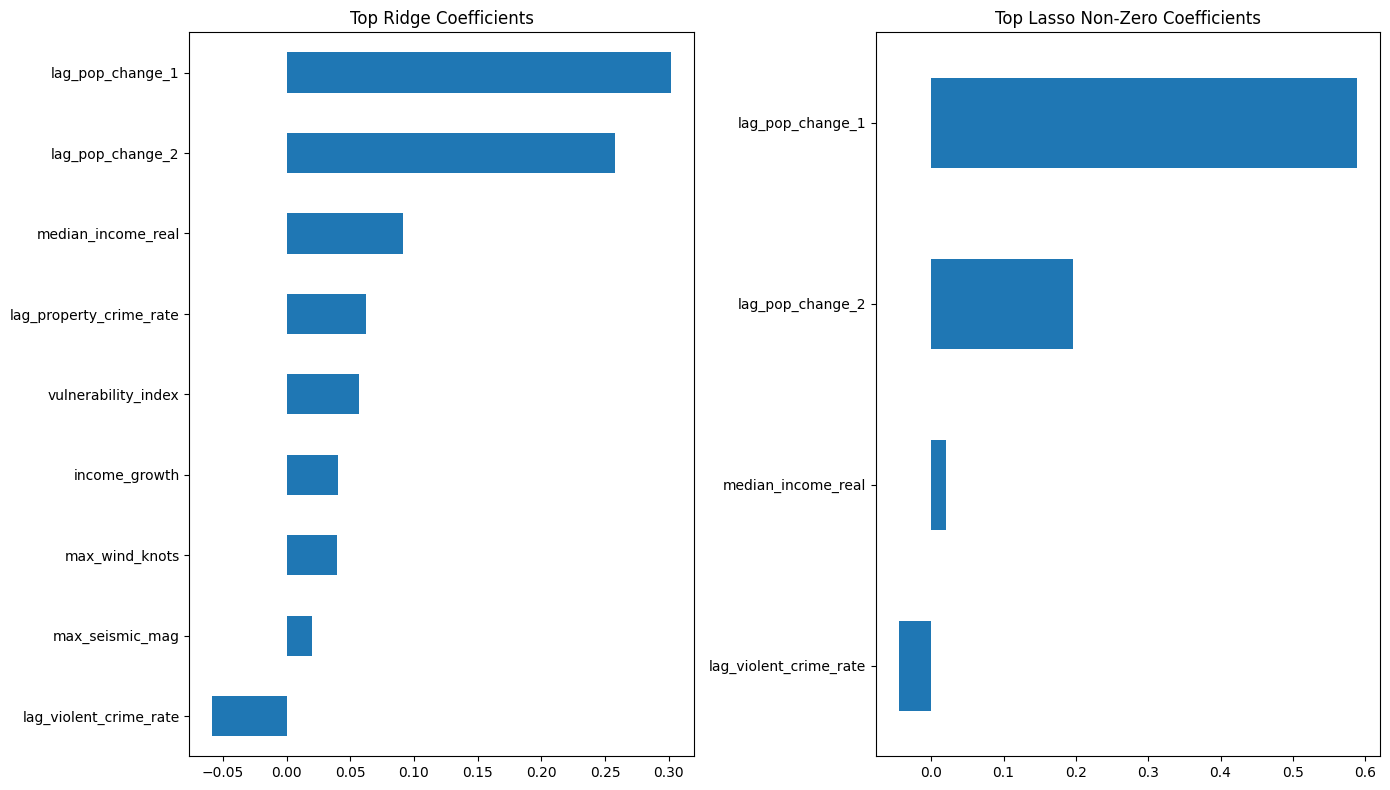

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ridge_coef.head(15).sort_values().plot(
    kind="barh", ax=axes[0], title="Top Ridge Coefficients"
)

lasso_nonzero = lasso_coef[lasso_coef != 0]
if len(lasso_nonzero) > 0:
    lasso_nonzero.head(15).sort_values().plot(
        kind="barh", ax=axes[1], title="Top Lasso Non-Zero Coefficients"
    )
else:
    axes[1].text(0.5, 0.5, "No non-zero Lasso coefficients", ha="center", va="center")
    axes[1].set_title("Top Lasso Non-Zero Coefficients")

plt.tight_layout()
plt.show()

## 9. Feature correlation diagnostics

Permutation importance can become unstable when predictors are correlated.  
This section provides a quick correlation check for the cleaned training features.

Interpretation note:
- strong positive or negative correlations can spread signal across multiple variables,
- sparse selection may keep only one of several related predictors,
- and negative permutation importance can reflect this shared structure rather than a feature being inherently unimportant.


,vulnerability_index,median_income_real,max_wind_knots,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2,income_growth
vulnerability_index,1.000,-0.653,-0.190,-0.138,-0.272,0.287,0.303,0.323,-0.011
median_income_real,-0.653,1.000,-0.059,-0.113,0.221,-0.021,0.202,0.188,0.036
max_wind_knots,-0.190,-0.059,1.000,0.100,0.122,-0.228,-0.234,-0.322,-0.000
max_seismic_mag,-0.138,-0.113,0.100,1.000,-0.157,-0.199,-0.251,-0.227,0.099
lag_violent_crime_rate,-0.272,0.221,0.122,-0.157,1.000,0.031,-0.016,-0.053,-0.008
lag_property_crime_rate,0.287,-0.021,-0.228,-0.199,0.031,1.000,0.318,0.316,-0.039
lag_pop_change_1,0.303,0.202,-0.234,-0.251,-0.016,0.318,1.000,0.864,-0.022
lag_pop_change_2,0.323,0.188,-0.322,-0.227,-0.053,0.316,0.864,1.000,-0.022
income_growth,-0.011,0.036,-0.000,0.099,-0.008,-0.039,-0.022,-0.022,1.000


,feature_1,feature_2,correlation,abs_correlation
61,lag_pop_change_1,lag_pop_change_2,0.864,0.864
1,vulnerability_index,median_income_real,-0.653,0.653
63,lag_pop_change_2,vulnerability_index,0.323,0.323
65,lag_pop_change_2,max_wind_knots,-0.322,0.322
59,lag_pop_change_1,lag_property_crime_rate,0.318,0.318
52,lag_property_crime_rate,lag_pop_change_2,0.316,0.316
54,lag_pop_change_1,vulnerability_index,0.303,0.303
45,lag_property_crime_rate,vulnerability_index,0.287,0.287
36,lag_violent_crime_rate,vulnerability_index,-0.272,0.272
57,lag_pop_change_1,max_seismic_mag,-0.251,0.251


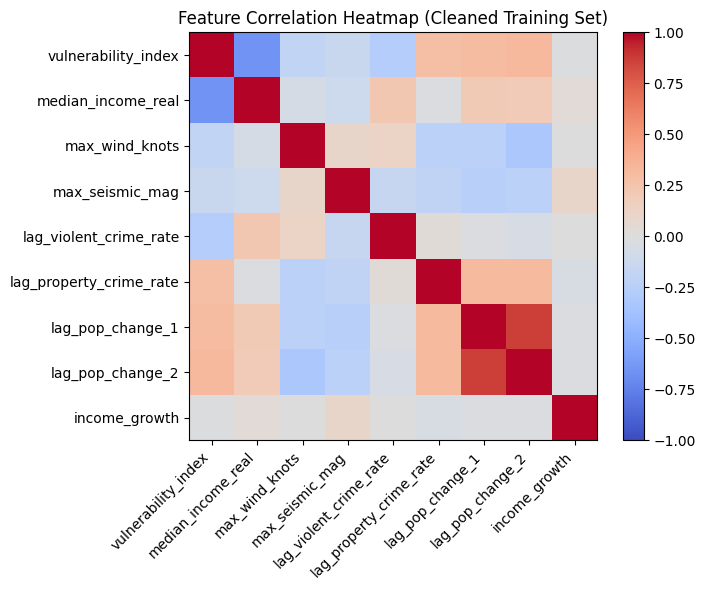

In [11]:
corr_df = X_train.corr(numeric_only=True)
display(corr_df.round(3))

mask = ~np.eye(len(corr_df), dtype=bool)
corr_pairs = (
    corr_df.where(mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)
# Drop duplicate mirrored pairs
corr_pairs["pair_key"] = corr_pairs.apply(lambda r: tuple(sorted((r['feature_1'], r['feature_2']))), axis=1)
corr_pairs = corr_pairs.drop_duplicates("pair_key").drop(columns="pair_key")
strong_corr_df = corr_pairs.head(10).copy()
display(strong_corr_df.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
ax.set_title('Feature Correlation Heatmap (Cleaned Training Set)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 10. Reconstruct the best Phase 2 tree model

This section rebuilds the best-performing Phase 2 nonlinear model using the saved parameter summary.
It supports:

- **Random Forest**
- **HistGradientBoosting**

The reconstructed model is then used for permutation importance, PDP/ICE diagnostics, and optional SHAP analysis.

In [12]:
best_model_name = phase2_summary.get("best_model_name", "Random Forest (tuned)")
rf_best_params = phase2_summary.get("rf_best_params", {})
hgb_best_params = phase2_summary.get(
    "hgb_best_params",
    phase2_summary.get("lgbm_best_params", {})
)

if "Random Forest" in best_model_name:
    tree_model = RandomForestRegressor(random_state=42, **rf_best_params)
elif "HistGradientBoosting" in best_model_name or "LightGBM" in best_model_name:
    tree_model = HistGradientBoostingRegressor(random_state=42, **hgb_best_params)
else:
    raise ValueError(f"Unsupported best model name: {best_model_name}")

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_metrics = {
    "model_name": best_model_name,
    "R2": float(r2_score(y_test, tree_pred)),
    "MAE": float(mean_absolute_error(y_test, tree_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, tree_pred)))
}

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{"model": best_model_name, "R2": tree_metrics["R2"], "MAE": tree_metrics["MAE"], "RMSE": tree_metrics["RMSE"], "alpha": np.nan}])
], ignore_index=True)

comparison_df

,model,R2,MAE,RMSE,alpha
0,Ridge (time-aware),-0.221036,1.805654,3.123859,316.227766
1,Lasso (time-aware),-0.229705,1.768759,3.134929,0.057362
2,Random Forest (tuned),-0.226586,1.745939,3.130951,NaN


## 11. Permutation importance

**Important interpretation note:** the reconstructed Phase 2 tree model may still have weak held-out performance.  
If held-out R² is negative, permutation importance should be treated as **unstable diagnostic evidence**, not as a definitive ranking.

Negative permutation importance means that permuting the feature **improved** held-out performance on average, which may reflect:
- weak signal
- correlation between features
- instability in a low-signal model

In [13]:
perm = permutation_importance(
    tree_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df["importance_mean_rounded"] = perm_df["importance_mean"].round(5)
perm_df["importance_std_rounded"] = perm_df["importance_std"].round(5)
perm_df["importance_sign"] = np.where(perm_df["importance_mean"] >= 0, "positive_or_zero", "negative")

display(perm_df[["feature", "importance_mean_rounded", "importance_std_rounded", "importance_sign"]])
print("Any negative permutation importances?", bool((perm_df["importance_mean"] < 0).any()))

,feature,importance_mean_rounded,importance_std_rounded,importance_sign
8,income_growth,0.00343,0.00530,positive_or_zero
3,max_seismic_mag,0.00246,0.00285,positive_or_zero
5,lag_property_crime_rate,0.00088,0.00151,positive_or_zero
4,lag_violent_crime_rate,0.00087,0.00216,positive_or_zero
1,median_income_real,0.00073,0.00111,positive_or_zero
2,max_wind_knots,-0.00013,0.00064,negative
0,vulnerability_index,-0.00174,0.00267,negative
7,lag_pop_change_2,-0.04061,0.02558,negative
6,lag_pop_change_1,-0.09266,0.02691,negative


Any negative permutation importances? True


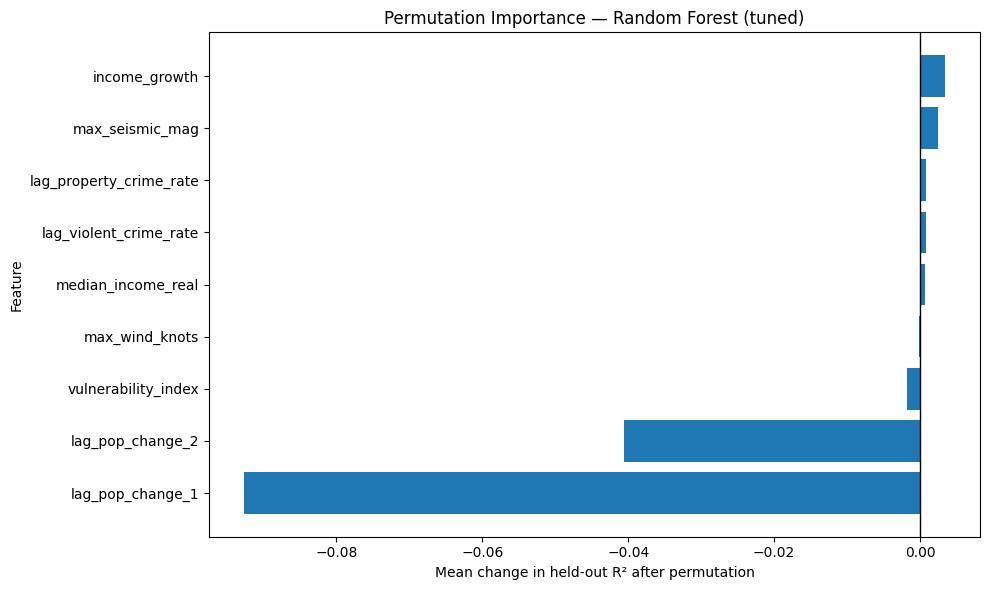

In [14]:
plt.figure(figsize=(10, 6))
plot_df = perm_df.sort_values("importance_mean")
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Permutation Importance — {best_model_name}")
plt.xlabel("Mean change in held-out R² after permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 12. Built-in tree feature importances (fallback-friendly)

If the selected tree model is a Random Forest, this section adds built-in impurity-based feature importances.
This provides a useful fallback explainability view even when SHAP is unavailable.

,feature,tree_feature_importance
6,lag_pop_change_1,0.489917
7,lag_pop_change_2,0.270850
5,lag_property_crime_rate,0.095342
4,lag_violent_crime_rate,0.038865
8,income_growth,0.036972
0,vulnerability_index,0.023442
1,median_income_real,0.020595
3,max_seismic_mag,0.016030
2,max_wind_knots,0.007986


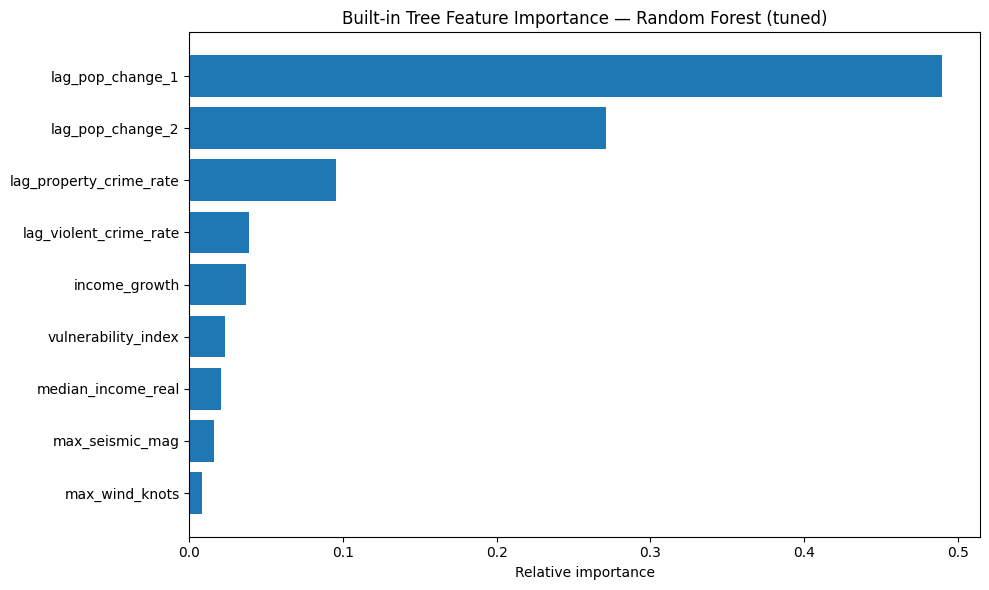

In [15]:
tree_builtin_importance_df = None

if hasattr(tree_model, "feature_importances_"):
    tree_builtin_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "tree_feature_importance": tree_model.feature_importances_
    }).sort_values("tree_feature_importance", ascending=False)

    display(tree_builtin_importance_df)

    plt.figure(figsize=(10, 6))
    plot_df = tree_builtin_importance_df.sort_values("tree_feature_importance")
    plt.barh(plot_df["feature"], plot_df["tree_feature_importance"])
    plt.title(f"Built-in Tree Feature Importance — {best_model_name}")
    plt.xlabel("Relative importance")
    plt.tight_layout()
    plt.show()
else:
    print("Selected tree model does not expose feature_importances_.")

## 13. Partial dependence / ICE plots

Rankings alone do not show **how** the nonlinear model responds across the feature range.
This section adds partial dependence and ICE diagnostics for a few candidate features.

These plots help answer:
- whether the model response is monotonic
- whether there are thresholds or plateaus
- whether local responses differ across observations

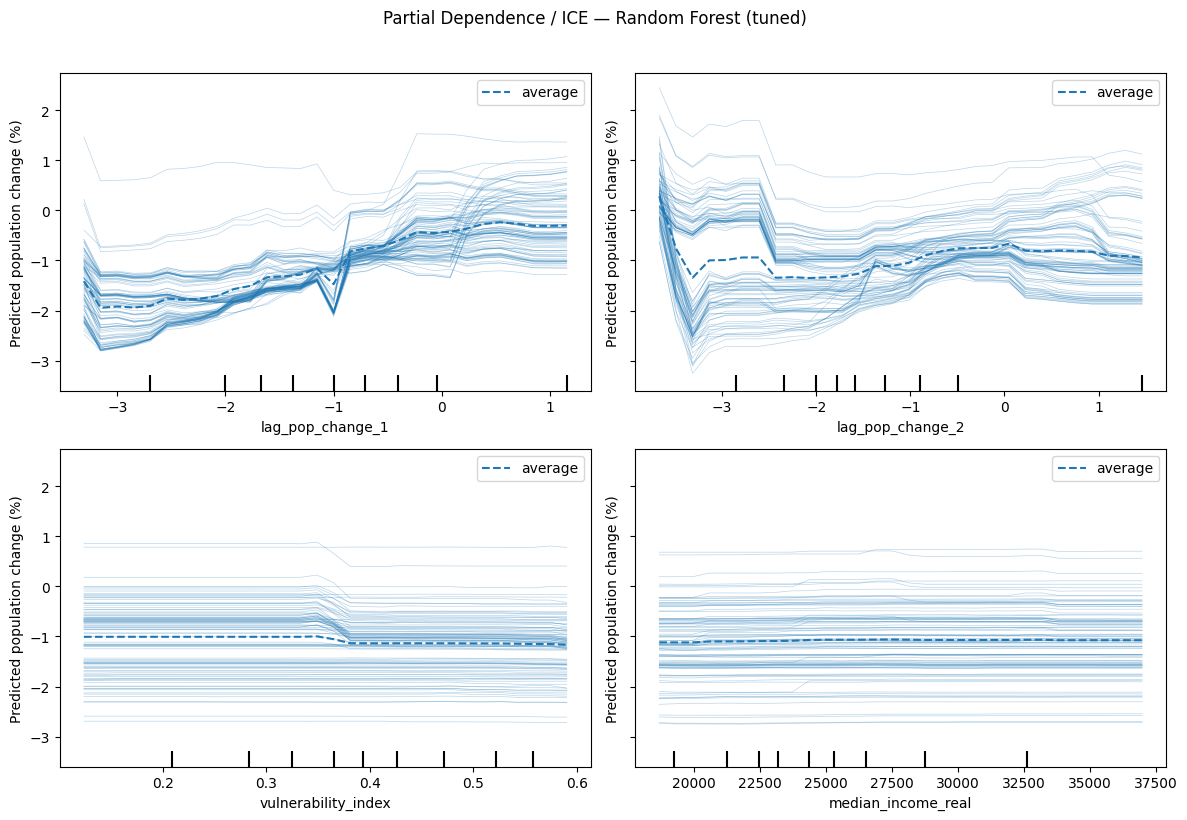

In [16]:
pdp_candidate_features = [
    "lag_pop_change_1",
    "lag_pop_change_2",
    "vulnerability_index",
    "median_income_real",
]
pdp_features = [f for f in pdp_candidate_features if f in feature_cols][:4]

if pdp_features:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    disp = PartialDependenceDisplay.from_estimator(
        tree_model,
        X_test,
        features=pdp_features,
        kind="both",
        subsample=min(100, len(X_test)),
        grid_resolution=30,
        ax=axes,
    )
    for ax in np.array(disp.axes_).ravel():
        if ax is not None:
            ax.set_ylabel("Predicted population change (%)")
    plt.suptitle(f"Partial Dependence / ICE — {best_model_name}", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No PDP candidate features found in the feature set.")


## 14. SHAP explainability (optional)

If the `shap` package is installed, this section will attempt to compute SHAP values.
If SHAP is not installed, the notebook will skip gracefully and continue running.

Even when SHAP is unavailable, this notebook still provides:
- permutation importance
- built-in tree feature importance (when available)
- partial dependence / ICE plots

In [17]:
shap_status = "not_run"
shap_top_df = None

try:
    import shap

    sample_n = min(200, len(X_test))
    X_shap = X_test.sample(n=sample_n, random_state=42) if len(X_test) > sample_n else X_test.copy()

    if isinstance(tree_model, RandomForestRegressor):
        shap_explainer = shap.TreeExplainer(tree_model)
        shap_values = shap_explainer.shap_values(X_shap)
        shap.summary_plot(shap_values, X_shap, show=False)
        plt.title(f"SHAP Summary Plot — {best_model_name}")
        plt.tight_layout()
        plt.show()

        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        shap_top_df = pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap
        }).sort_values("mean_abs_shap", ascending=False)

        shap_status = "completed_rf_treeexplainer"

    else:
        background = shap.sample(X_train, min(100, len(X_train)), random_state=42)
        shap_explainer = shap.Explainer(tree_model.predict, background)
        shap_values = shap_explainer(X_shap)

        shap.plots.beeswarm(shap_values, show=False)
        plt.title(f"SHAP Summary Plot — {best_model_name}")
        plt.tight_layout()
        plt.show()

        mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
        shap_top_df = pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap
        }).sort_values("mean_abs_shap", ascending=False)

        shap_status = "completed_generic_explainer"

except Exception as e:
    shap_status = f"skipped: {e}"
    print("SHAP section skipped:", e)

if shap_top_df is not None:
    display(shap_top_df)

shap_status

SHAP section skipped: No module named 'shap'


"skipped: No module named 'shap'"

## 15. Export explainability summary

In [18]:
export_perm_df = perm_df.copy()
export_perm_df["importance_mean"] = export_perm_df["importance_mean"].round(5)
export_perm_df["importance_std"] = export_perm_df["importance_std"].round(5)

explainability_summary = {
    "feature_set": feature_cols,
    "train_years": sorted(train_df["year"].unique().tolist()),
    "test_years": sorted(test_df["year"].unique().tolist()),
    "ridge_metrics": ridge_metrics,
    "lasso_metrics": lasso_metrics,
    "tree_model_metrics": tree_metrics,
    "comparison_table": comparison_df.to_dict(orient="records"),
    "lasso_nonzero_count": lasso_nonzero_count,
    "ridge_coefficients": ridge_coef.round(6).to_dict(),
    "lasso_coefficients": lasso_coef.round(6).to_dict(),
    "top_permutation_features": export_perm_df.head(15).to_dict(orient="records"),
    "permutation_contains_negative_values": bool((perm_df["importance_mean"] < 0).any()),
    "strongest_training_feature_correlations": strong_corr_df.round(5).to_dict(orient="records"),
    "tree_builtin_feature_importance": (
        tree_builtin_importance_df.round(6).to_dict(orient="records")
        if tree_builtin_importance_df is not None else None
    ),
    "shap_status": shap_status,
    "top_shap_features": (
        shap_top_df.head(15).round(6).to_dict(orient="records")
        if shap_top_df is not None else None
    ),
}

out_path = analysis_dir / "phase4_explainability_summary.json"
with open(out_path, "w") as f:
    json.dump(explainability_summary, f, indent=4)

print(f"Explainability summary saved to: {out_path}")


Explainability summary saved to: phase4_explainability_summary.json


## Phase 4 Conclusion: Model Explainability and Interpreting the Learned Structure

Phase 4 extends the project from prediction and scenario simulation into **model explainability**.  
The goal is not only to compare model performance, but to clarify **what the fitted models appear to learn** about municipal population change in Puerto Rico and how those patterns relate to the earlier forecasting results.

### Main interpretive points

- **Persistence remains the strongest linear signal.**  
  The time-aware Lasso solution retains only a small number of non-zero coefficients, with lagged population change terms clearly dominating. This indicates that the most consistent sparse linear forecasting signal in the current specification is short-run demographic momentum.

- **Ridge distributes signal across correlated predictors.**  
  Unlike Lasso, Ridge assigns non-zero weight to multiple variables, including income, vulnerability, and crime measures. This suggests that several predictors share overlapping information, which Ridge spreads across correlated features rather than selecting a single dominant one.

- **Tree-model explainability should be interpreted cautiously when held-out R² is weak.**  
  The reconstructed nonlinear model still exhibits negative out-of-sample R², meaning its predictive structure remains limited. In this setting, feature importance measures are best interpreted as **diagnostic indicators of model behavior**, not definitive evidence of causal or structural importance.

- **Negative permutation importance reflects instability rather than literal irrelevance.**  
  Some predictors—particularly lagged population variables—show negative permutation importance despite appearing important in SHAP and built-in tree importance rankings. This occurs when permuting a feature improves held-out predictions, typically because of correlated predictors or unstable model structure rather than because the feature is truly uninformative.

- **Partial dependence and ICE plots illustrate the model’s nonlinear response patterns.**  
  These plots reveal whether the tree model learns monotonic effects, thresholds, or largely flat responses across the observed feature range. In many cases, the responses remain relatively flat, reinforcing the conclusion that the current feature set produces limited robust nonlinear signal.

### What the explainability results reveal

Taken together, the explainability diagnostics reinforce several patterns observed earlier in **Phases 2 and 3**:

1. **Predictive structure remains limited.**  
   Even after model tuning and scenario simulation, the held-out predictive signal remains weak. This limits how strongly any importance ranking can be interpreted.

2. **Short-term demographic persistence dominates the sparse linear solution.**  
   The regularized models consistently identify recent population change as the most stable forecasting signal.

3. **Economic and vulnerability variables appear as secondary contributors.**  
   Ridge regression and tree-based diagnostics still assign moderate influence to these predictors, but the evidence is distributed across correlated features rather than concentrated in a single dominant variable.

4. **Disaster-related variables remain comparatively weak or unstable in this specification.**  
   This aligns with Phase 3’s scenario analysis, where simulated shocks produced relatively modest average changes in predicted population outcomes.

### Overall conclusion

Phase 4 adds value by making the forecasting pipeline more transparent and interpretable. The explainability analysis does not reveal a strong or stable explanatory structure in the current models; instead, it clarifies **where the available signal appears concentrated, where it remains diffuse, and where interpretation should remain cautious**.

This outcome is still informative. It suggests that the current feature set captures only a limited portion of the mechanisms driving municipal population change in Puerto Rico. Future improvements will likely require richer migration indicators, stronger spatial structure, and more informative temporal covariates to produce models that are both more predictive and more explainable.